In [10]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import numpy as np

In [11]:
df = pd.read_csv("/content/student_pass_prediction.csv")
df

,Study_Hours,Attendance,Previous_Score,Assignments,Pass
0,1,55,40,2,0
1,2,60,45,3,0
2,2,65,50,4,0
3,3,68,55,5,0
4,3,72,58,6,0
5,4,75,62,6,1
6,4,78,65,7,1
7,5,80,70,7,1
8,5,82,72,8,1
9,6,85,76,8,1


In [12]:
df.isnull().sum()

,0
Study_Hours,0
Attendance,0
Previous_Score,0
Assignments,0
Pass,0


In [13]:
X = df.drop("Pass",axis = 1)
Y = df["Pass"]

In [14]:
X_train,X_test,Y_train,Y_test =train_test_split(X,Y,test_size=0.5,random_state =42)

In [15]:
model = LogisticRegression()

In [16]:
model.fit(X_train,Y_train)

LogisticRegression()

In [17]:
prediction = model.predict(X_test)
print(prediction)
print(Y_test.values)
accuracy = accuracy_score(Y_test, prediction)

print("Accuracy:", accuracy*100)
cm = confusion_matrix(Y_test, prediction)

print(cm)

[0 1 0 0 1 1 1 0 1 0]
[0 1 0 0 1 1 1 0 1 0]
Accuracy: 100.0
[[5 0]
 [0 5]]


In [18]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

prediction = model.predict(X_test)

accuracy = accuracy_score(Y_test, prediction)

print("Accuracy")
print(accuracy*100)

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, prediction))

print("\nClassification Report")
print(classification_report(Y_test, prediction))

Accuracy
100.0

Confusion Matrix
[[5 0]
 [0 5]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [19]:
probability = model.predict_proba(X_test)

print(probability)

print(prediction)

[[9.99999990e-01 9.50117017e-09]
 [2.65086445e-04 9.99734914e-01]
 [9.99999915e-01 8.52803829e-08]
 [9.99999199e-01 8.01431365e-07]
 [4.43261660e-04 9.99556738e-01]
 [4.70208913e-01 5.29791087e-01]
 [6.00019010e-08 9.99999940e-01]
 [9.97609689e-01 2.39031055e-03]
 [2.10435337e-06 9.99997896e-01]
 [9.99992389e-01 7.61138581e-06]]
[0 1 0 0 1 1 1 0 1 0]


Input Features

↓

Linear Equation

↓

z

↓

Sigmoid Function

↓

Probability

↓

Threshold (0.5)

↓

Prediction

In [20]:
z = np.linspace(-10, 10, 100) # x xaxis
print (z)

[-10.          -9.7979798   -9.5959596   -9.39393939  -9.19191919
  -8.98989899  -8.78787879  -8.58585859  -8.38383838  -8.18181818
  -7.97979798  -7.77777778  -7.57575758  -7.37373737  -7.17171717
  -6.96969697  -6.76767677  -6.56565657  -6.36363636  -6.16161616
  -5.95959596  -5.75757576  -5.55555556  -5.35353535  -5.15151515
  -4.94949495  -4.74747475  -4.54545455  -4.34343434  -4.14141414
  -3.93939394  -3.73737374  -3.53535354  -3.33333333  -3.13131313
  -2.92929293  -2.72727273  -2.52525253  -2.32323232  -2.12121212
  -1.91919192  -1.71717172  -1.51515152  -1.31313131  -1.11111111
  -0.90909091  -0.70707071  -0.50505051  -0.3030303   -0.1010101
   0.1010101    0.3030303    0.50505051   0.70707071   0.90909091
   1.11111111   1.31313131   1.51515152   1.71717172   1.91919192
   2.12121212   2.32323232   2.52525253   2.72727273   2.92929293
   3.13131313   3.33333333   3.53535354   3.73737374   3.93939394
   4.14141414   4.34343434   4.54545455   4.74747475   4.94949495
   5.151515

In [21]:
probabilities = 1 / (1 + np.exp(-z)) #sigmod function formula 1/1+e^z  #y axis
print(probabilities)

[4.53978687e-05 5.55606489e-05 6.79983174e-05 8.32200197e-05
 1.01848815e-04 1.24647146e-04 1.52547986e-04 1.86692945e-04
 2.28478855e-04 2.79614739e-04 3.42191434e-04 4.18766684e-04
 5.12469082e-04 6.27124987e-04 7.67413430e-04 9.39055039e-04
 1.14904229e-03 1.40591988e-03 1.72012560e-03 2.10440443e-03
 2.57431039e-03 3.14881358e-03 3.85103236e-03 4.70911357e-03
 5.75728612e-03 7.03711536e-03 8.59898661e-03 1.05038445e-02
 1.28252101e-02 1.56514861e-02 1.90885420e-02 2.32625358e-02
 2.83228820e-02 3.44451957e-02 4.18339400e-02 5.07243606e-02
 6.13831074e-02 7.41067363e-02 8.92170603e-02 1.07052146e-01
 1.27951705e-01 1.52235823e-01 1.80176593e-01 2.11963334e-01
 2.47663801e-01 2.87185901e-01 3.30246430e-01 3.76354517e-01
 4.24816868e-01 4.74768924e-01 5.25231076e-01 5.75183132e-01
 6.23645483e-01 6.69753570e-01 7.12814099e-01 7.52336199e-01
 7.88036666e-01 8.19823407e-01 8.47764177e-01 8.72048295e-01
 8.92947854e-01 9.10782940e-01 9.25893264e-01 9.38616893e-01
 9.49275639e-01 9.581660

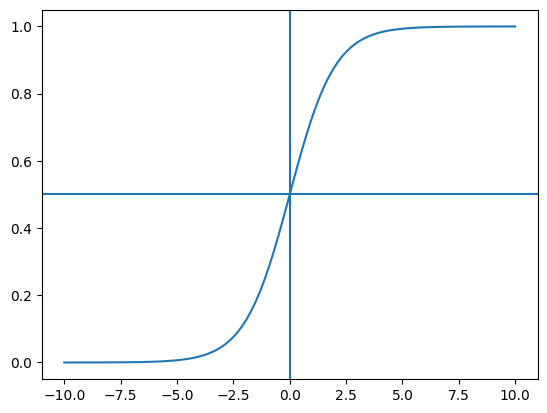

In [22]:
plt.plot(z, probabilities)
plt.axhline(y=0.5) #threshold (0.5)
plt.axvline(x=0)

In [23]:
print(model.coef_)

print(model.intercept_)

[[0.06439223 0.4013256  0.45780406 0.07494464]]
[-59.07120272]


In [24]:
z = (
    0.06439223 * 6
    + 0.4013256 * 85
    + 0.45780406 * 80
    + 0.07494464 * 8
    - 59.07120272
)

print(z)

12.651708580000005


LOAN APRROVAL DATASET MODEL


In [25]:
df= pd.read_csv("/content/loan_approval_dataset.csv")
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Education_Graduate,Married,Property_Area_Urban,Loan_Status
0,2500,0,90,360,1,1,0,1,1
1,1800,1200,120,360,1,1,1,0,1
2,1200,0,110,360,0,0,0,0,0
3,4000,1500,180,360,1,1,1,1,1
4,1500,0,130,360,0,0,0,0,0


In [26]:
X = df[["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term",
       "Credit_History","Education_Graduate","Married","Property_Area_Urban"]]
Y = df["Loan_Status"]


In [27]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.5,random_state = 42)

In [28]:
model = LogisticRegression()

In [29]:
model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [30]:
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 0 1 1 1 1 1 0]


In [31]:
loan_status_labels = ['Not Approved', 'Approved']
predicted_labels = [loan_status_labels[label] for label in y_pred]
print("Predicted Loan Status:")
print(predicted_labels)

Predicted Loan Status:
['Approved', 'Approved', 'Approved', 'Not Approved', 'Approved', 'Approved', 'Approved', 'Approved', 'Approved', 'Not Approved']


In [32]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

prediction = model.predict(X_test)

accuracy = accuracy_score(Y_test, prediction)

print("Accuracy")
print(accuracy*100)

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, prediction))

print("\nClassification Report")
print(classification_report(Y_test, prediction))

Accuracy
90.0

Confusion Matrix
[[1 0]
 [1 8]]

Classification Report
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.89      0.94         9

    accuracy                           0.90        10
   macro avg       0.75      0.94      0.80        10
weighted avg       0.95      0.90      0.91        10



In [33]:
new_applicant = pd.DataFrame({
    "ApplicantIncome": [4500],
    "CoapplicantIncome": [1500],
    "LoanAmount": [180],
    "Loan_Amount_Term": [360],
    "Credit_History": [1],
    "Education_Graduate": [1],
    "Married": [1],
    "Property_Area_Urban": [1]
})
predict = model.predict(new_applicant)
predicted = [loan_status_labels[label] for label in predict]
print(predicted)

['Approved']


In [34]:
new_applicant = pd.DataFrame({
    "ApplicantIncome": [1200],
    "CoapplicantIncome": [0],
    "LoanAmount": [150],
    "Loan_Amount_Term": [180],
    "Credit_History": [0],
    "Education_Graduate": [0],
    "Married": [0],
    "Property_Area_Urban": [0]
})
predict = model.predict(new_applicant)
predicte = [loan_status_labels[label] for label in predict]
print(predicte)

['Not Approved']


In [35]:
print(model.coef_)

print(model.intercept_)

[[ 4.20785333e-02 -7.76138958e-03 -1.28654687e-04  2.51100305e-04
  -8.21017024e-05 -1.13583705e-04 -1.55406069e-04 -1.86888075e-04]]
[-78.55383015]


Distribution of Loan Status ⭐

Purpose: Check whether the dataset is balanced.

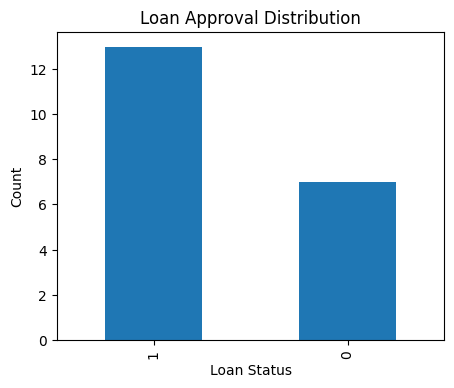

In [36]:
import matplotlib.pyplot as plt

df["Loan_Status"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

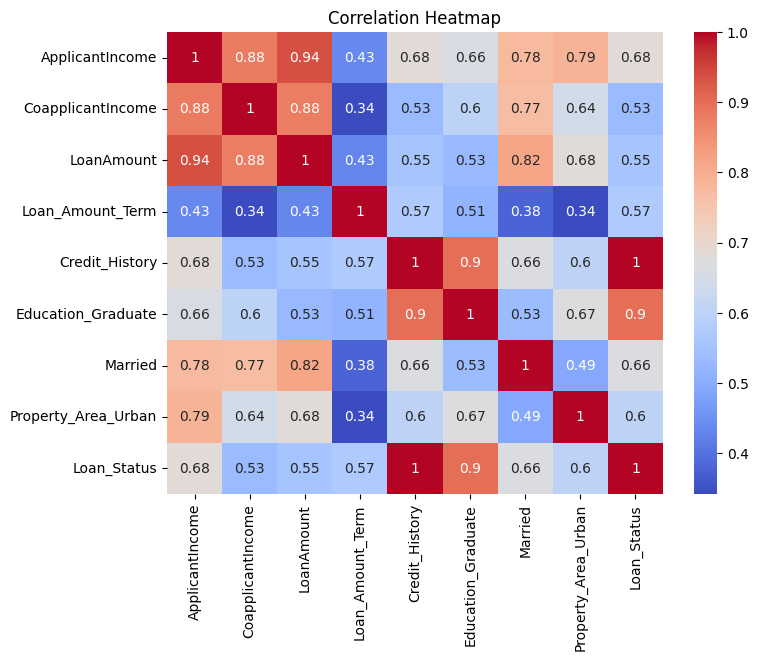

In [37]:
import seaborn as sns
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

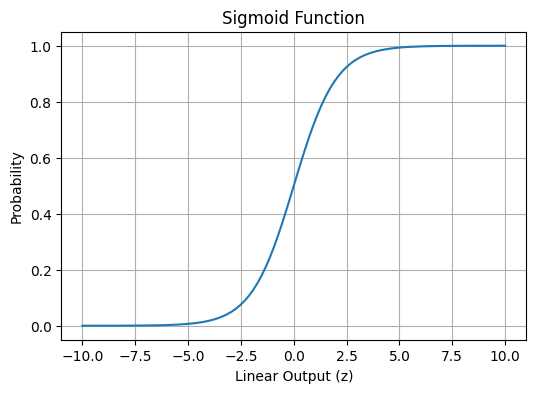

In [38]:
import numpy as np

x = np.linspace(-10,10,100)

y = 1/(1+np.exp(-x))

plt.figure(figsize=(6,4))

plt.plot(x,y)

plt.title("Sigmoid Function")
plt.xlabel("Linear Output (z)")
plt.ylabel("Probability")

plt.grid(True)

plt.show()

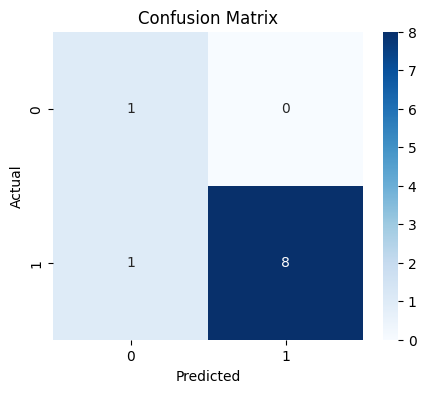

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()